# Multi-Factor Portfolio Research Framework — Indian Equities
## Notebook 03 — Portfolio Construction

Consumes Notebook 02's factor panel (composite score, monthly grid) and constructs portfolio holdings:
Top-20 stock selection, two weighting schemes (Equal Weight and True Equal Risk Contribution), across
three rebalancing frequencies (Monthly / Quarterly / Semi-Annual).

## Objective

Convert the composite factor score into explicit portfolio weights — which stocks are held, and how
much of the portfolio each receives — under two weighting schemes and three rebalancing frequencies,
producing the six (frequency × scheme) weight panels that Notebook 04 will compound into a
walk-forward backtest.

## Research Questions Addressed

This notebook resolves the weighting-methodology and rebalancing-frequency-sensitivity dimensions of
the project's research scope: does risk-based weighting (ERC) differ meaningfully from naive Equal
Weight, and how does portfolio composition and turnover vary with rebalancing frequency. It does not
address performance (Notebook 04) or attribution (Notebook 05).

## Scope Boundary

This notebook produces weights only. No returns are compounded, no performance metrics are computed,
and no transaction costs are applied here — that is Notebook 04 (Walk-Forward Backtest) and Notebook 05
(Portfolio Analytics)'s role. Per the standing project convention, no starting capital or "portfolio
value" language appears anywhere below.

## Design Decisions (confirmed prior to implementation)

- **Liquidity filter:** no additional liquidity/traded-value filter is applied beyond the history
  requirement already implicit in the factor panel (a stock needs all four factor z-scores present,
  which itself requires approximately 756 trading days of history for Maximum Drawdown/Beta). The
  point-in-time coverage question flagged in Notebooks 01/02 is resolved as "the history requirement
  alone is sufficient," an explicit choice rather than an implicit assumption.
- **ERC covariance lookback:** 756 trading days, matching the Maximum Drawdown/Beta window elsewhere
  in the project, for consistency across the factor and risk model.
- **Under-sized eligible universe (fewer than 20 stocks) at a rebalance date:** construct the portfolio
  from all eligible stocks available that date (portfolio temporarily below 20), log the event
  explicitly, and do not modify any filtering rule to compensate.

## Inputs

- `data/factor_panel.csv`, `data/rebalance_dates.csv`, `data/eligible_universe_size.csv` (Notebook 02).
- `data/daily_returns.csv`, `data/master_universe.csv`, `data/study_window.json`,
  `data/amfi_membership_matrix.csv` (Notebook 01).

## Outputs

- `data/portfolio_holdings.csv` — long-format weights for every `(rebalance_date, frequency,
  weighting_scheme, ticker)` combination.
- `data/portfolio_selection_log.csv`, `data/erc_diagnostics_log.csv`,
  `data/portfolio_concentration.csv` — construction-stage diagnostics.
- `data/ticker_sector_map.csv`, `data/ranked_universe_panel.csv`,
  `data/portfolio_turnover_log.csv`, `data/selection_frequency.csv`, `data/sector_allocation.csv`,
  `data/capclass_allocation.csv` — Portfolio Research section outputs (see below).

## Assumptions

- Target portfolio size: Top 20 by composite score.
- Rebalancing frequencies subset Notebook 02's monthly grid (every 1st / 3rd / 6th month-end) rather
  than recomputing factors at coarser granularity.
- ERC minimum observation threshold: 100 daily returns; below this, the optimizer falls back to Equal
  Weight for that (date, frequency) combination, logged rather than silently applied.
- Covariance matrices with condition number above $10^6$ are shrunk toward their diagonal (10%
  shrinkage intensity) before optimization.
- Risk-free rate 0%, 20 bps default transaction cost (not applied in this notebook; carried forward
  for Notebook 05's cost sensitivity sweep).

## Environment Setup

In [1]:
!pip install pandas numpy matplotlib scipy yfinance --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\vidya\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


### Configuration: Portfolio Construction Parameters (Locked)

Defines the target portfolio size, the three rebalancing-frequency step sizes (subsetting Notebook
02's monthly grid), the two weighting schemes, and the ERC optimizer settings (covariance lookback,
minimum observations, shrinkage threshold and intensity). Also defines parameters used only by the
Portfolio Research section further below (buffer rank range, chart sizes) — these do not feed back
into construction.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
import os
import json

warnings.filterwarnings('ignore')

BASE_DIR   = '.'
DATA_DIR   = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
#  ▶▶  PORTFOLIO CONSTRUCTION PARAMETERS (locked)  ◀◀
# ══════════════════════════════════════════════════════════════════════════════
TARGET_PORTFOLIO_SIZE = 20   # Top-20 by composite score

# Rebalance frequencies -- all subset from NB02's monthly grid (every Nth month-end)
REBAL_FREQ_STEP = {
    'Monthly':     1,
    'Quarterly':   3,
    'SemiAnnual':  6,
}

WEIGHTING_SCHEMES = ['EqualWeight', 'ERC']

# True ERC optimizer settings
ERC_COV_LOOKBACK_DAYS = 756   # matches Max Drawdown / Beta window, for consistency (locked)
ERC_MIN_OBS           = 100   # minimum daily-return observations required to attempt ERC at all;
                               # below this, covariance estimates are too noisy to trust -- falls
                               # back to Equal Weight for that (date, frequency) combination, logged
ERC_MAX_ITER          = 500
ERC_COND_NUMBER_FLAG  = 1e6   # covariance matrices with condition number above this are flagged as
                               # near-singular/degenerate in diagnostics and shrunk toward their
                               # diagonal before optimization (see Cell 8)
ERC_SHRINKAGE_ALPHA   = 0.10  # shrinkage intensity applied ONLY to flagged near-singular matrices
                               # (blend toward a diagonal target of the same average variance) --
                               # a light regularisation, not a general-purpose shrinkage estimator

ANN_FACTOR       = 252
RISK_FREE_RATE   = 0.0
DEFAULT_COST_BPS = 20   # not applied in this notebook -- carried forward for NB05 sensitivity sweep

# ══════════════════════════════════════════════════════════════════════════════
#  ▶▶  PORTFOLIO RESEARCH SECTION PARAMETERS (research/interpretation only --
#      see the Portfolio Research section below; none of this feeds back into
#      the construction logic above)  ◀◀
# ══════════════════════════════════════════════════════════════════════════════
BUFFER_RANK_START = 21   # buffer/watchlist = ranks 21-30 (just outside the Top 20)
BUFFER_RANK_END   = 30
RANK_CHART_TOP_N  = 30   # how many ranks to show in the composite-score ranking chart
TOP_FREQ_CHART_N  = 20   # how many tickers to show in the selection-frequency chart

# -- Visual style: identical to Notebooks 01/02, reused across the whole project --
DARK_BG    = '#0D0D0D'
PANEL_BG   = '#1A1A1A'
COLORS     = ['#29B6F6', '#FF7043', '#66BB6A', '#CE93D8', '#FFB300',
              '#F48FB1', '#80DEEA', '#FFCC02', '#A5D6A7', '#EF9A9A']
ACCENT     = '#00FF88'
ACCENT2    = '#FF5252'
GRID_COLOR = '#2A2A2A'
TEXT_COLOR = '#E0E0E0'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,   'axes.facecolor':  DARK_BG,
    'savefig.facecolor': DARK_BG,
    'axes.edgecolor':   GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'xtick.color':      TEXT_COLOR, 'ytick.color':     TEXT_COLOR,
    'text.color':       TEXT_COLOR, 'grid.color':      GRID_COLOR,
    'grid.linestyle':   '--',       'grid.alpha':      0.4,
    'font.family':      'monospace',
    'legend.facecolor': PANEL_BG,  'legend.edgecolor': GRID_COLOR,
})

print('Configuration loaded (Notebook 03 -- Portfolio Construction).')
print(f'  Target portfolio size : {TARGET_PORTFOLIO_SIZE} stocks')
print(f'  Rebalance frequencies : {list(REBAL_FREQ_STEP.keys())}')
print(f'  Weighting schemes     : {WEIGHTING_SCHEMES}')
print(f'  ERC covariance window : {ERC_COV_LOOKBACK_DAYS}d (~3yr, matches Max DD / Beta)')


Configuration loaded (Notebook 03 -- Portfolio Construction).
  Target portfolio size : 20 stocks
  Rebalance frequencies : ['Monthly', 'Quarterly', 'SemiAnnual']
  Weighting schemes     : ['EqualWeight', 'ERC']
  ERC covariance window : 756d (~3yr, matches Max DD / Beta)


### Load Notebook 01 and Notebook 02 Outputs

Loads the long-format factor panel, the monthly rebalance grid, daily returns, the master universe
list, and the study window, then reconstructs the wide `(rebalance_date × ticker)` composite score
panel from the long factor panel for ranking.

In [3]:
factor_panel_long = pd.read_csv(os.path.join(DATA_DIR, 'factor_panel.csv'),
                                 parse_dates=['rebalance_date'])
rebalance_dates_all = pd.to_datetime(
    pd.read_csv(os.path.join(DATA_DIR, 'rebalance_dates.csv'))['rebalance_date']
)
eligible_universe_size = pd.read_csv(
    os.path.join(DATA_DIR, 'eligible_universe_size.csv'), index_col=0, parse_dates=True
).iloc[:, 0]

daily_returns = pd.read_csv(os.path.join(DATA_DIR, 'daily_returns.csv'), index_col=0, parse_dates=True)
master_universe = pd.read_csv(os.path.join(DATA_DIR, 'master_universe.csv'))['ticker'].tolist()

with open(os.path.join(DATA_DIR, 'study_window.json'), 'r') as f:
    _sw = json.load(f)
WARMUP_START   = _sw.get('warmup_start',   '2015-07-01')
BACKTEST_START = _sw.get('backtest_start', '2018-07-01')
END_DATE       = _sw.get('end_date',       daily_returns.index[-1].strftime('%Y-%m-%d'))

# Composite score panel, wide (rebalance_date x ticker) -- reconstructed from the long factor panel
composite_score_panel = factor_panel_long.pivot(
    index='rebalance_date', columns='ticker', values='composite_score'
).reindex(columns=master_universe)

print(f'Factor panel (long)       : {factor_panel_long.shape}')
print(f'Composite score (wide)    : {composite_score_panel.shape}')
print(f'Rebalance dates (monthly) : {len(rebalance_dates_all)}')
print(f'Daily returns             : {daily_returns.shape}')
print(f'Study window              : warm-up {WARMUP_START} / backtest {BACKTEST_START} -> {END_DATE}')


Factor panel (long)       : (35262, 9)
Composite score (wide)    : (97, 404)
Rebalance dates (monthly) : 97
Daily returns             : (2755, 404)
Study window              : warm-up 2015-07-01 / backtest 2018-07-01 -> 2026-07-16


### Subset the Monthly Rebalance Grid by Frequency

Notebook 02 computed the factor panel once at monthly granularity. Quarterly and Semi-Annual grids are
subset from it (every 3rd / every 6th month-end) rather than recomputed, per the locked project design
— factors are never computed three times over.

In [4]:
monthly_dates = pd.DatetimeIndex(sorted(rebalance_dates_all.unique()))

REBAL_DATES_BY_FREQ = {}
for freq_name, step in REBAL_FREQ_STEP.items():
    REBAL_DATES_BY_FREQ[freq_name] = monthly_dates[::step]

for freq_name, dates in REBAL_DATES_BY_FREQ.items():
    print(f'{freq_name:12s}: {len(dates):3d} rebalance dates  '
          f'({dates[0].date()} -> {dates[-1].date()})')


Monthly     :  97 rebalance dates  (2018-07-31 -> 2026-07-15)
Quarterly   :  33 rebalance dates  (2018-07-31 -> 2026-07-15)
SemiAnnual  :  17 rebalance dates  (2018-07-31 -> 2026-07-15)


### Top-20 Selection per Rebalance Date and Frequency

Eligibility rule (unchanged from Notebook 02, no additional liquidity filter): a stock is eligible at
a rebalance date if its composite score is non-null there, i.e., all four factor z-scores were
computable — which itself implies sufficient trailing history. Stocks are ranked by composite score,
descending, and the Top 20 are selected. If fewer than 20 are eligible, all eligible stocks are taken
and the shortfall is logged; no filtering rule is relaxed or tightened to compensate.

In [5]:
def select_top_n(rebalance_date, scores_panel, n=TARGET_PORTFOLIO_SIZE):
    """Return a Series of composite scores for the selected stocks at one rebalance date,
    sorted descending, index = ticker. Length is min(n, number of eligible stocks)."""
    row = scores_panel.loc[rebalance_date].dropna()
    ranked = row.sort_values(ascending=False)
    return ranked.iloc[:n]


selection_log_rows = []
SELECTIONS = {}   # (freq_name, rebalance_date) -> pd.Series of selected tickers -> composite score

for freq_name, dates in REBAL_DATES_BY_FREQ.items():
    for rd in dates:
        selected = select_top_n(rd, composite_score_panel)
        SELECTIONS[(freq_name, rd)] = selected
        n_eligible_total = composite_score_panel.loc[rd].notna().sum()
        selection_log_rows.append({
            'frequency': freq_name,
            'rebalance_date': rd,
            'n_eligible_total': n_eligible_total,
            'n_selected': len(selected),
            'under_target': len(selected) < TARGET_PORTFOLIO_SIZE,
        })

selection_log = pd.DataFrame(selection_log_rows)
n_under_target = selection_log['under_target'].sum()

print(f'Selections built for {len(SELECTIONS)} (frequency, rebalance_date) combinations.')
print(f'Rebalance dates with fewer than {TARGET_PORTFOLIO_SIZE} eligible stocks: '
      f'{n_under_target} / {len(selection_log)}')
if n_under_target > 0:
    print('These use all eligible stocks that date (portfolio temporarily undersized), logged below:')
    print(selection_log[selection_log['under_target']].to_string(index=False))
else:
    print('Every (frequency, rebalance_date) combination reached the full target of '
          f'{TARGET_PORTFOLIO_SIZE} stocks.')


Selections built for 147 (frequency, rebalance_date) combinations.
Rebalance dates with fewer than 20 eligible stocks: 0 / 147
Every (frequency, rebalance_date) combination reached the full target of 20 stocks.


Every one of the 147 (frequency, rebalance date) combinations reached the full 20-stock
target — no rebalance date required the under-sized-portfolio fallback described above.

### Diagnostic: Portfolio Size Over Time, by Frequency

Confirms the 20-stock target is met at every rebalance date across all three frequencies, visually.

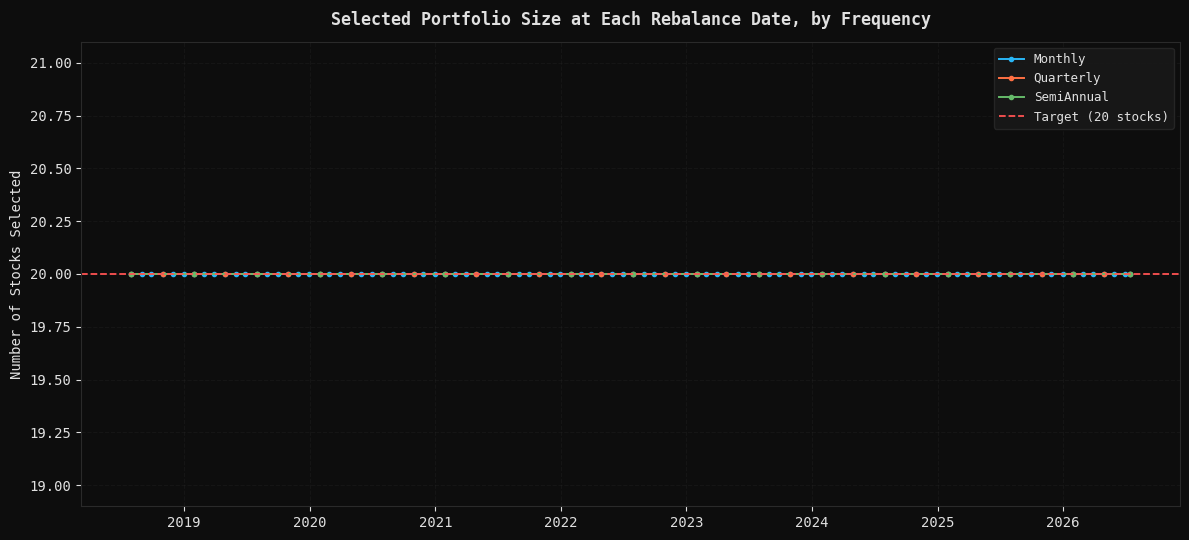

Saved -> .\output\03_portfolio_size_over_time.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5.5))
for i, freq_name in enumerate(REBAL_FREQ_STEP.keys()):
    sub = selection_log[selection_log['frequency'] == freq_name]
    ax.plot(sub['rebalance_date'], sub['n_selected'], color=COLORS[i], linewidth=1.4,
            marker='o', markersize=3, label=freq_name)

ax.axhline(TARGET_PORTFOLIO_SIZE, color=ACCENT2, linestyle='--', linewidth=1.3,
           label=f'Target ({TARGET_PORTFOLIO_SIZE} stocks)')
ax.set_title('Selected Portfolio Size at Each Rebalance Date, by Frequency',
              fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)
ax.set_ylabel('Number of Stocks Selected')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_portfolio_size_over_time.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Equal Weight Scheme

$$w_i = \frac{1}{N}, \qquad i = 1, \dots, N$$

for each of the $N$ selected stocks at a given rebalance date.

In [7]:
def equal_weights(selected_scores):
    """selected_scores: pd.Series indexed by ticker (composite scores, any values).
    Returns pd.Series of weights indexed by the same tickers, summing to 1."""
    n = len(selected_scores)
    return pd.Series(1.0 / n, index=selected_scores.index)


# Quick sanity check on one rebalance date
_sample_key = list(SELECTIONS.keys())[0]
_sample_ew = equal_weights(SELECTIONS[_sample_key])
print(f'Sample ({_sample_key[0]}, {_sample_key[1].date()}): '
      f'{len(_sample_ew)} stocks, weights sum to {_sample_ew.sum():.6f}, '
      f'each weight = {_sample_ew.iloc[0]:.4f}')


Sample (Monthly, 2018-07-31): 20 stocks, weights sum to 1.000000, each weight = 0.0500


### True Equal Risk Contribution (ERC) Optimizer

Solved via `scipy.optimize` for weights where each stock contributes equally to total portfolio risk —
not naive inverse-volatility weighting. Long-only ($w_i \in [0, 1]$), fully invested ($\sum_i w_i = 1$),
no leverage.

Portfolio variance and each stock's risk contribution:
$$\sigma_p^2 = w^\top \Sigma w, \qquad
\text{RC}_i = w_i \, (\Sigma w)_i$$

The ERC objective minimizes the dispersion of risk contributions around their equal-split target:
$$\min_w \ \sum_{i=1}^{N} \left( \text{RC}_i - \frac{\sigma_p^2}{N} \right)^2
\quad \text{s.t.} \quad \sum_i w_i = 1, \ \ w_i \ge 0$$

Covariance $\Sigma$ is estimated from the trailing 756 trading days of daily returns ending at each
rebalance date (matching the Maximum Drawdown/Beta window elsewhere in the project). If fewer than
`ERC_MIN_OBS` (100) observations are available for a stock at a given rebalance date — possible only
very early in the backtest, or for a very recently listed stock within the selected Top 20 — the
optimizer falls back to Equal Weight for that (date, frequency) combination and logs it explicitly,
rather than silently dropping the stock or raising an error.

Covariance matrices with a high condition number (near-singular — common when trailing history is
short relative to the number of selected stocks, or when several selected stocks are highly collinear)
are shrunk toward their diagonal (light regularisation) before optimization, and the event is logged in
`erc_diagnostics_log`.

In [8]:
from scipy.optimize import minimize

erc_diagnostics_rows = []


def estimate_covariance(tickers, rebalance_date, lookback=ERC_COV_LOOKBACK_DAYS):
    """Trailing covariance matrix (annualised) for the given tickers, using daily returns
    strictly before rebalance_date. Returns (cov_matrix_df, n_obs_used, was_shrunk,
    original_cond_number) -- the condition number returned is always the PRE-shrinkage value,
    so the diagnostic log shows how near-singular the raw estimate actually was, not the
    (necessarily well-conditioned) post-shrinkage result."""
    window = daily_returns.loc[:rebalance_date, tickers]
    window = window.iloc[:-1] if len(window) > 0 and window.index[-1] == rebalance_date else window
    window = window.tail(lookback)

    clean = window.dropna(how='any')
    if len(clean) < 2:
        return None, len(clean), False, np.nan

    cov = clean.cov().values * ANN_FACTOR
    was_shrunk = False
    original_cond_number = np.linalg.cond(cov)

    if original_cond_number > ERC_COND_NUMBER_FLAG:
        avg_var = np.mean(np.diag(cov))
        diag_target = np.eye(len(tickers)) * avg_var
        cov = (1 - ERC_SHRINKAGE_ALPHA) * cov + ERC_SHRINKAGE_ALPHA * diag_target
        was_shrunk = True

    return pd.DataFrame(cov, index=tickers, columns=tickers), len(clean), was_shrunk, original_cond_number


def erc_objective(w, cov_matrix):
    port_var = w @ cov_matrix @ w
    marginal_contrib = cov_matrix @ w
    risk_contrib = w * marginal_contrib
    target = port_var / len(w)
    return np.sum((risk_contrib - target) ** 2)


def solve_erc(selected_scores, rebalance_date):
    """Returns (weights: pd.Series, method_used: str) where method_used is 'ERC' or
    'EqualWeight_fallback'."""
    tickers = list(selected_scores.index)
    n = len(tickers)

    cov_df, n_obs, was_shrunk, cond_number = estimate_covariance(tickers, rebalance_date)

    if cov_df is None or n_obs < ERC_MIN_OBS:
        erc_diagnostics_rows.append({
            'rebalance_date': rebalance_date, 'n_stocks': n, 'n_obs_used': n_obs,
            'cond_number': np.nan, 'was_shrunk': False, 'fallback_to_ew': True,
            'optimizer_converged': np.nan,
        })
        return equal_weights(selected_scores), 'EqualWeight_fallback'

    cov = cov_df.values

    w0 = np.full(n, 1.0 / n)
    bounds = [(1e-6, 1.0) for _ in range(n)]
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

    result = minimize(
        erc_objective, w0, args=(cov,), method='SLSQP',
        bounds=bounds, constraints=constraints,
        options={'maxiter': ERC_MAX_ITER, 'ftol': 1e-12},
    )

    erc_diagnostics_rows.append({
        'rebalance_date': rebalance_date, 'n_stocks': n, 'n_obs_used': n_obs,
        'cond_number': cond_number, 'was_shrunk': was_shrunk, 'fallback_to_ew': False,
        'optimizer_converged': bool(result.success),
    })

    if not result.success:
        return equal_weights(selected_scores), 'EqualWeight_fallback'

    w = np.clip(result.x, 0, None)
    w = w / w.sum()
    return pd.Series(w, index=tickers), 'ERC'


# Quick sanity check on the same sample rebalance date used in Cell 7
_sample_erc_w, _sample_method = solve_erc(SELECTIONS[_sample_key], _sample_key[1])
print(f'Sample ({_sample_key[0]}, {_sample_key[1].date()}): method={_sample_method}, '
      f'weights sum to {_sample_erc_w.sum():.6f}, '
      f'min={_sample_erc_w.min():.4f}, max={_sample_erc_w.max():.4f}')


Sample (Monthly, 2018-07-31): method=ERC, weights sum to 1.000000, min=0.0280, max=0.0849


A sample sanity check (Monthly, 2018-07-31) confirms both schemes produce weights summing
to 1.0: Equal Weight assigns 5.00% to each of the 20 stocks; ERC assigns weights ranging from 2.80% to
8.49% across the same 20 stocks, reflecting the risk-based tilt.

### Build the Portfolio Holdings Panel (All Frequencies × Both Weighting Schemes)

Iterates both weighting schemes over every (frequency, rebalance date) selection, producing the
long-format holdings panel consumed by Notebook 04, together with a weight-sum sanity check and a
summary of ERC fallback/shrinkage events.

In [9]:
holdings_rows = []

for (freq_name, rd), selected_scores in SELECTIONS.items():
    ew = equal_weights(selected_scores)
    for ticker, w in ew.items():
        holdings_rows.append({
            'rebalance_date': rd, 'frequency': freq_name,
            'weighting_scheme': 'EqualWeight', 'ticker': ticker, 'weight': w,
        })

    erc_w, erc_method = solve_erc(selected_scores, rd)
    for ticker, w in erc_w.items():
        holdings_rows.append({
            'rebalance_date': rd, 'frequency': freq_name,
            'weighting_scheme': 'ERC', 'ticker': ticker, 'weight': w,
        })

portfolio_holdings = pd.DataFrame(holdings_rows)
erc_diagnostics_log = pd.DataFrame(erc_diagnostics_rows)

print(f'Portfolio holdings panel: {portfolio_holdings.shape[0]} rows '
      f'({portfolio_holdings[["frequency", "weighting_scheme"]].drop_duplicates().shape[0]} '
      f'frequency x scheme combinations)')

_weight_sums = portfolio_holdings.groupby(['frequency', 'weighting_scheme', 'rebalance_date'])['weight'].sum()
_bad_sums = _weight_sums[(_weight_sums - 1.0).abs() > 1e-6]
print(f'Weight-sum sanity check: {len(_bad_sums)} / {len(_weight_sums)} '
      f'(frequency, scheme, date) groups do not sum to 1.0 (should be 0)')

n_shrunk = erc_diagnostics_log['was_shrunk'].sum()
n_fallback = erc_diagnostics_log['fallback_to_ew'].sum()
n_not_converged = (erc_diagnostics_log['optimizer_converged'] == False).sum()
print(f'ERC diagnostics: {n_shrunk} covariance matrices shrunk (near-singular), '
      f'{n_fallback} fell back to Equal Weight (insufficient history), '
      f'{n_not_converged} optimizer non-convergences (fell back to Equal Weight)')


Portfolio holdings panel: 5880 rows (6 frequency x scheme combinations)
Weight-sum sanity check: 0 / 294 (frequency, scheme, date) groups do not sum to 1.0 (should be 0)
ERC diagnostics: 65 covariance matrices shrunk (near-singular), 0 fell back to Equal Weight (insufficient history), 0 optimizer non-convergences (fell back to Equal Weight)


### Diagnostic: Weight Distribution Sanity Checks (ERC vs. Equal Weight)

Concentration is measured via the Herfindahl–Hirschman Index (HHI, sum of squared weights) and its
inverse, effective number of stocks:

$$\text{HHI} = \sum_{i=1}^{N} w_i^2, \qquad \text{Effective } N = \frac{1}{\text{HHI}}$$

Equal Weight over $N$ stocks always has an effective $N$ of exactly $N$; ERC's effective $N$ is
expected to be somewhat lower — it tilts away from the highest-volatility or most-correlated names,
which is the intended behaviour, not a flaw.

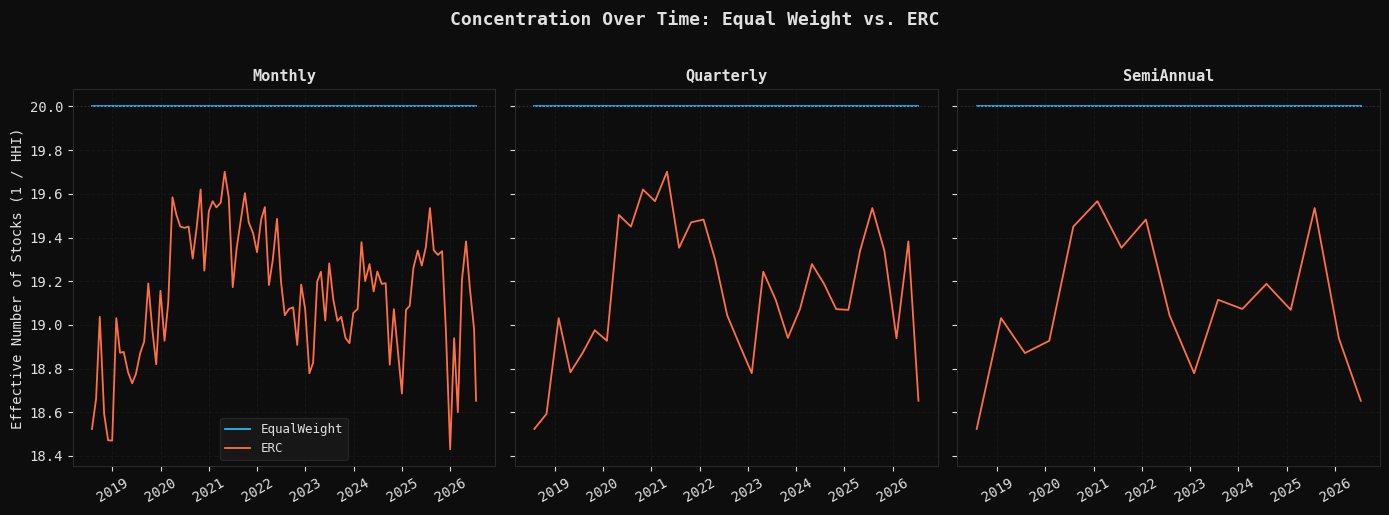

Saved -> .\output\03_weight_concentration_ew_vs_erc.png

Median effective N by frequency and scheme:
frequency   weighting_scheme
Monthly     ERC                 19.17
            EqualWeight         20.00
Quarterly   ERC                 19.11
            EqualWeight         20.00
SemiAnnual  ERC                 19.07
            EqualWeight         20.00


In [10]:
def herfindahl(weights):
    return np.sum(weights ** 2)


concentration_rows = []
for (freq_name, scheme), grp in portfolio_holdings.groupby(['frequency', 'weighting_scheme']):
    for rd, sub in grp.groupby('rebalance_date'):
        hhi = herfindahl(sub['weight'].values)
        concentration_rows.append({
            'frequency': freq_name, 'weighting_scheme': scheme, 'rebalance_date': rd,
            'hhi': hhi, 'effective_n': 1.0 / hhi, 'max_weight': sub['weight'].max(),
        })

concentration_df = pd.DataFrame(concentration_rows)

fig, axes = plt.subplots(1, len(REBAL_FREQ_STEP), figsize=(14, 5), sharey=True)
for ax, freq_name in zip(axes, REBAL_FREQ_STEP.keys()):
    for i, scheme in enumerate(WEIGHTING_SCHEMES):
        sub = concentration_df[(concentration_df['frequency'] == freq_name) &
                                (concentration_df['weighting_scheme'] == scheme)]
        ax.plot(sub['rebalance_date'], sub['effective_n'], color=COLORS[i], linewidth=1.3,
                label=scheme)
    ax.set_title(freq_name, fontsize=11, fontweight='bold', color=TEXT_COLOR)
    ax.axhline(TARGET_PORTFOLIO_SIZE, color=GRID_COLOR, linestyle=':', linewidth=1.0)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Effective Number of Stocks (1 / HHI)')
axes[0].legend(fontsize=9)
fig.suptitle('Concentration Over Time: Equal Weight vs. ERC', fontsize=13, fontweight='bold',
             color=TEXT_COLOR, y=1.02)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_weight_concentration_ew_vs_erc.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')

print()
print('Median effective N by frequency and scheme:')
print(concentration_df.groupby(['frequency', 'weighting_scheme'])['effective_n']
      .median().round(2).to_string())


Median effective N confirms the expected pattern: Equal Weight holds at exactly 20.00
across all three frequencies, while ERC's effective N is marginally lower — 19.17 (Monthly), 19.11
(Quarterly), 19.07 (Semi-Annual) — a modest, not extreme, concentration tilt relative to Equal Weight.

### Diagnostic: ERC Optimizer Robustness (Near-Singular Covariance and Fallbacks)

Surfaces every (frequency, rebalance date) combination where the ERC optimizer either fell back to
Equal Weight because too few return observations were available, required covariance shrinkage because
the raw covariance matrix was near-singular, or failed to converge. This is the explicit stress-test
the project's testing discipline requires — these events are logged, not hidden.

In [11]:
flagged = erc_diagnostics_log[
    erc_diagnostics_log['was_shrunk'] |
    erc_diagnostics_log['fallback_to_ew'] |
    (erc_diagnostics_log['optimizer_converged'] == False)
].copy()

print(f'Flagged ERC events: {len(flagged)} / {len(erc_diagnostics_log)} '
      f'(frequency, rebalance_date) combinations')

if len(flagged) > 0:
    print()
    print(flagged.sort_values('rebalance_date').to_string(index=False))
    print()
    print('These typically cluster at the very start of the backtest window (limited trailing '
          'history right after BACKTEST_START), which is expected -- if they appear scattered '
          'throughout the backtest instead, that would warrant investigation.')
else:
    print('No near-singular covariance matrices, insufficient-history fallbacks, or optimizer '
          'non-convergences across the full backtest window.')


Flagged ERC events: 65 / 148 (frequency, rebalance_date) combinations

rebalance_date  n_stocks  n_obs_used  cond_number  was_shrunk  fallback_to_ew  optimizer_converged
    2018-08-31        20         756 2.990278e+17        True           False                 True
    2018-09-28        20         756 3.984378e+16        True           False                 True
    2018-10-31        20         756 2.554831e+16        True           False                 True
    2018-10-31        20         756 2.554831e+16        True           False                 True
    2018-11-30        20         756 6.337147e+15        True           False                 True
    2018-12-31        20         756 9.638099e+16        True           False                 True
    2019-01-31        20         638 2.125786e+16        True           False                 True
    2019-01-31        20         638 2.125786e+16        True           False                 True
    2019-01-31        20         638 2

65 of 148 logged ERC attempts (147 construction-stage calls plus one earlier sanity-check
call) required covariance shrinkage due to a near-singular raw estimate; none fell back to Equal
Weight for insufficient history, and none failed to converge. Flagged events cluster at the start of
the backtest window, consistent with limited trailing history immediately after `BACKTEST_START` —
the expected pattern, not a sign of a broader estimation problem.

### Save Portfolio Holdings Panel and Diagnostics to data/

Persists the holdings panel and the three construction-stage diagnostic logs (selection, ERC
diagnostics, concentration) consumed by Notebook 04 and referenced in Notebook 05.

In [12]:
portfolio_holdings.to_csv(os.path.join(DATA_DIR, 'portfolio_holdings.csv'), index=False)
selection_log.to_csv(os.path.join(DATA_DIR, 'portfolio_selection_log.csv'), index=False)
erc_diagnostics_log.to_csv(os.path.join(DATA_DIR, 'erc_diagnostics_log.csv'), index=False)
concentration_df.to_csv(os.path.join(DATA_DIR, 'portfolio_concentration.csv'), index=False)

print('Saved to data/:')
for f in ['portfolio_holdings.csv', 'portfolio_selection_log.csv',
          'erc_diagnostics_log.csv', 'portfolio_concentration.csv']:
    print(f'  {f}')

print()
print('=' * 60)
print('NOTEBOOK 03 -- COMPLETE')
print('=' * 60)
print(f'  Frequencies              : {list(REBAL_FREQ_STEP.keys())}')
print(f'  Weighting schemes        : {WEIGHTING_SCHEMES}')
print(f'  Target portfolio size    : {TARGET_PORTFOLIO_SIZE} stocks')
print(f'  Under-target rebalances  : {n_under_target} / {len(selection_log)}')
print(f'  ERC fallbacks / shrinkage: {n_fallback} fallback, {n_shrunk} shrunk, '
      f'{n_not_converged} non-converged')
print()
print('  Charts in output/:')
for f in ['03_portfolio_size_over_time.png', '03_weight_concentration_ew_vs_erc.png']:
    print(f'    {f}')
print()
print('  Next -> Notebook 04: Walk-Forward Backtest')


Saved to data/:
  portfolio_holdings.csv
  portfolio_selection_log.csv
  erc_diagnostics_log.csv
  portfolio_concentration.csv

NOTEBOOK 03 -- COMPLETE
  Frequencies              : ['Monthly', 'Quarterly', 'SemiAnnual']
  Weighting schemes        : ['EqualWeight', 'ERC']
  Target portfolio size    : 20 stocks
  Under-target rebalances  : 0 / 147
  ERC fallbacks / shrinkage: 0 fallback, 65 shrunk, 0 non-converged

  Charts in output/:
    03_portfolio_size_over_time.png
    03_weight_concentration_ew_vs_erc.png

  Next -> Notebook 04: Walk-Forward Backtest


---
## Portfolio Research Section

This section is for research interpretation and portfolio review only. Every output below (ranked-
universe panel, tables, charts, turnover logs, selection-frequency statistics) is computed strictly
after the portfolio construction logic above has already run and been saved. Nothing in this section
feeds back into stock selection, weighting, or the Top-20 cutoff — it exists to give a portfolio
manager an interpretable view of why the portfolio looks the way it does at any given rebalance.

**Sector/Industry data source:** the project's original plan deferred yfinance `sector`/`industry`
fetching to Notebook 05. That work is brought forward here instead, cached once per ticker to
`data/ticker_sector_map.csv` so Notebook 05 can reuse it without re-fetching. Coverage is expected to
be imperfect for some NSE mid-caps (a known, disclosed yfinance limitation, not a bug); any ticker with
missing data is explicitly labelled `'Unknown'`, never silently dropped.

### Dark-Themed Table Renderer (Shared Helper for This Section)

A single reusable function renders any DataFrame as a dark-themed matplotlib table and saves it to
`output/`, used by every tabular research output in this section.

In [13]:
def render_dark_table(df, title, filename, col_widths=None, highlight_rows=None,
                       figsize=None, header_color=ACCENT):
    """Renders a pandas DataFrame as a dark-themed matplotlib table, saves it to output/,
    and displays it inline. highlight_rows (optional): iterable of row indices (0-based, into
    df, not including the header) to tint slightly differently (e.g. to mark ERC-fallback rows)."""
    n_rows, n_cols = df.shape
    fig_w = figsize[0] if figsize else max(9, 1.35 * n_cols)
    fig_h = figsize[1] if figsize else max(1.6, 0.42 * n_rows + 1.3)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')

    tbl = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center',
                   colWidths=col_widths)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1, 1.7)

    highlight_rows = set(highlight_rows) if highlight_rows else set()
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(GRID_COLOR)
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color=DARK_BG, fontsize=10)
        else:
            data_row = row - 1
            if data_row in highlight_rows:
                cell.set_facecolor('#22331F')
            else:
                cell.set_facecolor(PANEL_BG if data_row % 2 == 0 else DARK_BG)
            cell.set_text_props(color=TEXT_COLOR)

    ax.set_title(title, fontsize=13, fontweight='bold', color=TEXT_COLOR, pad=16)
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    print(f'Saved -> {path}')
    return path


print('Dark table renderer ready.')


Dark table renderer ready.


### Sector and Industry Metadata (yfinance, Cached Per Ticker)

Sector and industry do not change per rebalance date, so this is fetched — or loaded from cache — once
per ticker in the master universe, rather than once per rebalance date.

In [14]:
import yfinance as yf

SECTOR_MAP_FILE = os.path.join(DATA_DIR, 'ticker_sector_map.csv')

if os.path.exists(SECTOR_MAP_FILE):
    sector_map = pd.read_csv(SECTOR_MAP_FILE, index_col='ticker')
    print(f'Loaded cached sector/industry map for {len(sector_map)} tickers '
          f'from {SECTOR_MAP_FILE}')
else:
    print(f'Fetching sector/industry for {len(master_universe)} tickers via yfinance ...')
    sector_rows = []
    for i, t in enumerate(master_universe):
        try:
            info = yf.Ticker(t).info
            sector = info.get('sector') or 'Unknown'
            industry = info.get('industry') or 'Unknown'
        except Exception:
            sector, industry = 'Unknown', 'Unknown'
        sector_rows.append({'ticker': t, 'sector': sector, 'industry': industry})
        if (i + 1) % 25 == 0:
            print(f'  ... {i + 1} / {len(master_universe)}')

    sector_map = pd.DataFrame(sector_rows).set_index('ticker')
    sector_map.to_csv(SECTOR_MAP_FILE)
    print(f'Saved sector/industry map -> {SECTOR_MAP_FILE}')

n_unknown_sector = (sector_map['sector'] == 'Unknown').sum()
print(f'Sector coverage: {len(sector_map) - n_unknown_sector} / {len(sector_map)} tickers '
      f'have a known sector ({n_unknown_sector} Unknown -- disclosed, not hidden; yfinance '
      f'sector/industry coverage is known to be patchy for some NSE mid-caps).')


Fetching sector/industry for 404 tickers via yfinance ...
  ... 25 / 404


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BAJAJAUTO.NS"}}}


  ... 50 / 404
  ... 75 / 404
  ... 100 / 404
  ... 125 / 404
  ... 150 / 404
  ... 175 / 404
  ... 200 / 404
  ... 225 / 404
  ... 250 / 404


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: NAMINDIA.NS"}}}


  ... 275 / 404
  ... 300 / 404
  ... 325 / 404
  ... 350 / 404
  ... 375 / 404
  ... 400 / 404
Saved sector/industry map -> .\data\ticker_sector_map.csv
Sector coverage: 383 / 404 tickers have a known sector (21 Unknown -- disclosed, not hidden; yfinance sector/industry coverage is known to be patchy for some NSE mid-caps).


Sector coverage: 383 of 404 tickers (94.8%) have a known sector; 21 are labelled
`Unknown`, disclosed rather than hidden — consistent with yfinance's known patchy sector/industry
coverage for some NSE mid-caps.

### AMFI Large/Mid Classification, As-Of Each Rebalance Date

Unlike sector/industry, AMFI classification genuinely changes over time (a stock can move from Mid Cap
to Large Cap between AMFI snapshots), so this is looked up "as of" each rebalance date — the most
recent AMFI snapshot on or before that date — rather than fetched once per ticker. Reuses Notebook 01's
`amfi_membership_matrix.csv`; no new download is required.

In [15]:
amfi_membership_matrix = pd.read_csv(
    os.path.join(DATA_DIR, 'amfi_membership_matrix.csv'), index_col=0
)
amfi_membership_matrix.columns = pd.to_datetime(amfi_membership_matrix.columns)


def amfi_class_asof_series(rebalance_date):
    """Returns a pd.Series indexed by ticker, giving each ticker's AMFI classification
    ('Large Cap' / 'Mid Cap') as of the most recent snapshot on or before rebalance_date.
    Tickers with no snapshot yet available, or not in the matrix, are 'Unknown'."""
    valid_snaps = amfi_membership_matrix.columns[amfi_membership_matrix.columns <= rebalance_date]
    if len(valid_snaps) == 0:
        return pd.Series('Unknown', index=amfi_membership_matrix.index)
    latest_snap = valid_snaps.max()
    return amfi_membership_matrix[latest_snap].fillna('Unknown')


_sample_asof = amfi_class_asof_series(monthly_dates[-1])
print(f'Sample as-of classification ({monthly_dates[-1].date()}): '
      f'{_sample_asof.value_counts().to_dict()}')


Sample as-of classification (2026-07-15): {'Unknown': 193, 'Mid Cap': 148, 'Large Cap': 100}


### Build the Full Ranked-Universe Panel (Research Only)

For every (frequency, rebalance date), every eligible stock — not only the selected Top 20 — is
recorded with its rank, composite score, individual factor z-scores, sector, industry, AMFI
classification, both weighting schemes (populated only for selected stocks; missing for unselected
stocks, which reflects the absence of a position rather than missing data), and an explicit selection
flag. This is strictly a reporting view built from data already produced by the construction cells
above.

In [16]:
ranked_universe_rows = []

for freq_name, dates in REBAL_DATES_BY_FREQ.items():
    for rd in dates:
        eligible_scores = composite_score_panel.loc[rd].dropna().sort_values(ascending=False)
        if len(eligible_scores) == 0:
            continue

        factor_row = factor_panel_long[factor_panel_long['rebalance_date'] == rd].set_index('ticker')
        amfi_asof = amfi_class_asof_series(rd)

        selected_scores = SELECTIONS[(freq_name, rd)]
        selected_tickers = set(selected_scores.index)
        ew_weights = equal_weights(selected_scores) if len(selected_scores) > 0 else pd.Series(dtype=float)

        erc_weights_row = portfolio_holdings[
            (portfolio_holdings['frequency'] == freq_name) &
            (portfolio_holdings['rebalance_date'] == rd) &
            (portfolio_holdings['weighting_scheme'] == 'ERC')
        ].set_index('ticker')['weight']

        for rank, (ticker, score) in enumerate(eligible_scores.items(), start=1):
            f_row = factor_row.loc[ticker] if ticker in factor_row.index else None
            ranked_universe_rows.append({
                'frequency':           freq_name,
                'rebalance_date':      rd,
                'rank':                rank,
                'ticker':              ticker,
                'composite_score':     score,
                'momentum_z':          f_row['momentum_z'] if f_row is not None else np.nan,
                'low_vol_z':           f_row['low_vol_z'] if f_row is not None else np.nan,
                'max_dd_z':            f_row['max_dd_z'] if f_row is not None else np.nan,
                'beta_z':              f_row['beta_z'] if f_row is not None else np.nan,
                'sector':              sector_map.loc[ticker, 'sector'] if ticker in sector_map.index else 'Unknown',
                'industry':            sector_map.loc[ticker, 'industry'] if ticker in sector_map.index else 'Unknown',
                'amfi_classification': amfi_asof.get(ticker, 'Unknown'),
                'equal_weight':        ew_weights.get(ticker, np.nan),
                'erc_weight':          erc_weights_row.get(ticker, np.nan),
                'selected_top20':      ticker in selected_tickers,
            })

ranked_universe_panel = pd.DataFrame(ranked_universe_rows)

print(f'Ranked-universe panel: {ranked_universe_panel.shape[0]} rows '
      f'(all eligible stocks, all frequencies, all rebalance dates)')
print(f'  Selected (Top 20) rows : {ranked_universe_panel["selected_top20"].sum()}')
print(f'  Non-selected rows      : {(~ranked_universe_panel["selected_top20"]).sum()}')


Ranked-universe panel: 49071 rows (all eligible stocks, all frequencies, all rebalance dates)
  Selected (Top 20) rows : 2940
  Non-selected rows      : 46131


The ranked-universe panel contains 49,071 rows across all eligible stocks, frequencies,
and rebalance dates — 2,940 of which are selected (Top-20) rows and 46,131 non-selected, giving the
buffer/watchlist and ranking views below their full eligible-universe context.

### Save the Ranked-Universe Panel

In [17]:
ranked_universe_panel.to_csv(os.path.join(DATA_DIR, 'ranked_universe_panel.csv'), index=False)
print(f'Saved -> {os.path.join(DATA_DIR, "ranked_universe_panel.csv")}')
print(f'  {ranked_universe_panel.shape[0]} rows x {ranked_universe_panel.shape[1]} columns')


Saved -> .\data\ranked_universe_panel.csv
  49071 rows x 15 columns


### Research Output 1: Top-20 Portfolio Table (Latest Rebalance, per Frequency)

Renders the current Top-20 holdings — rank, composite score, sector, AMFI classification, and both
weighting schemes' weights — for the most recent rebalance date under each frequency.

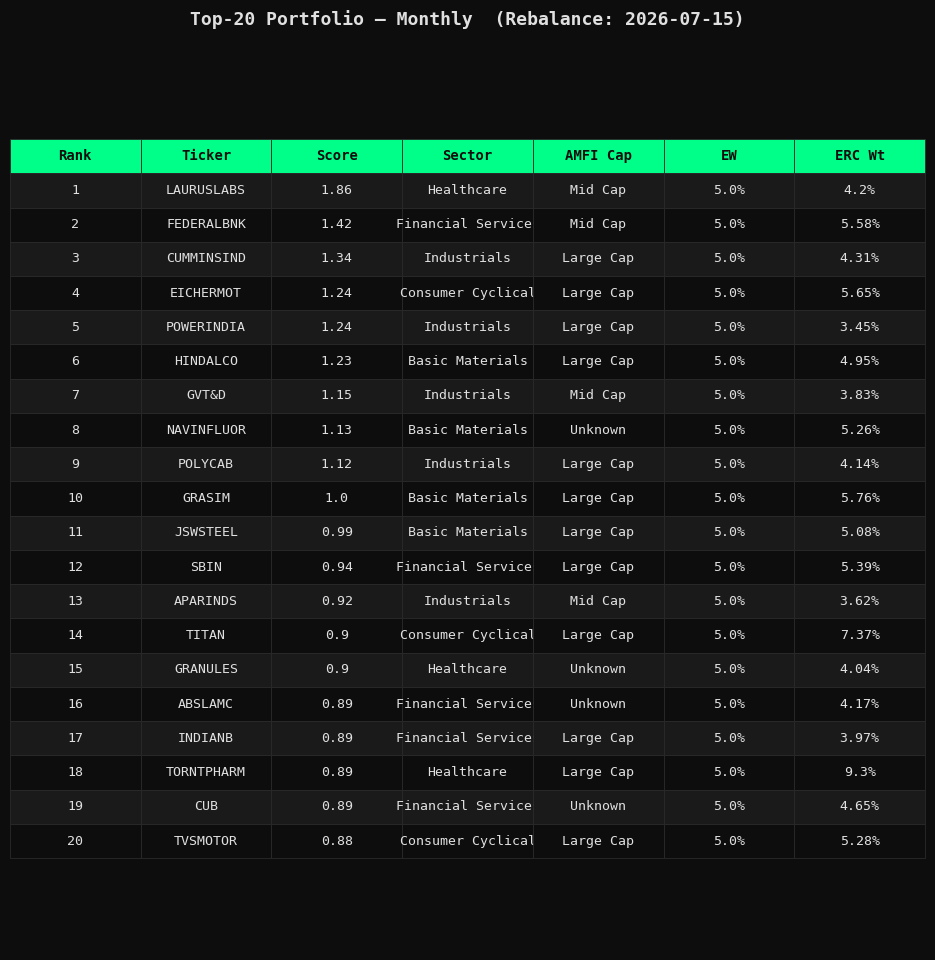

Saved -> .\output\03_research_top20_monthly.png


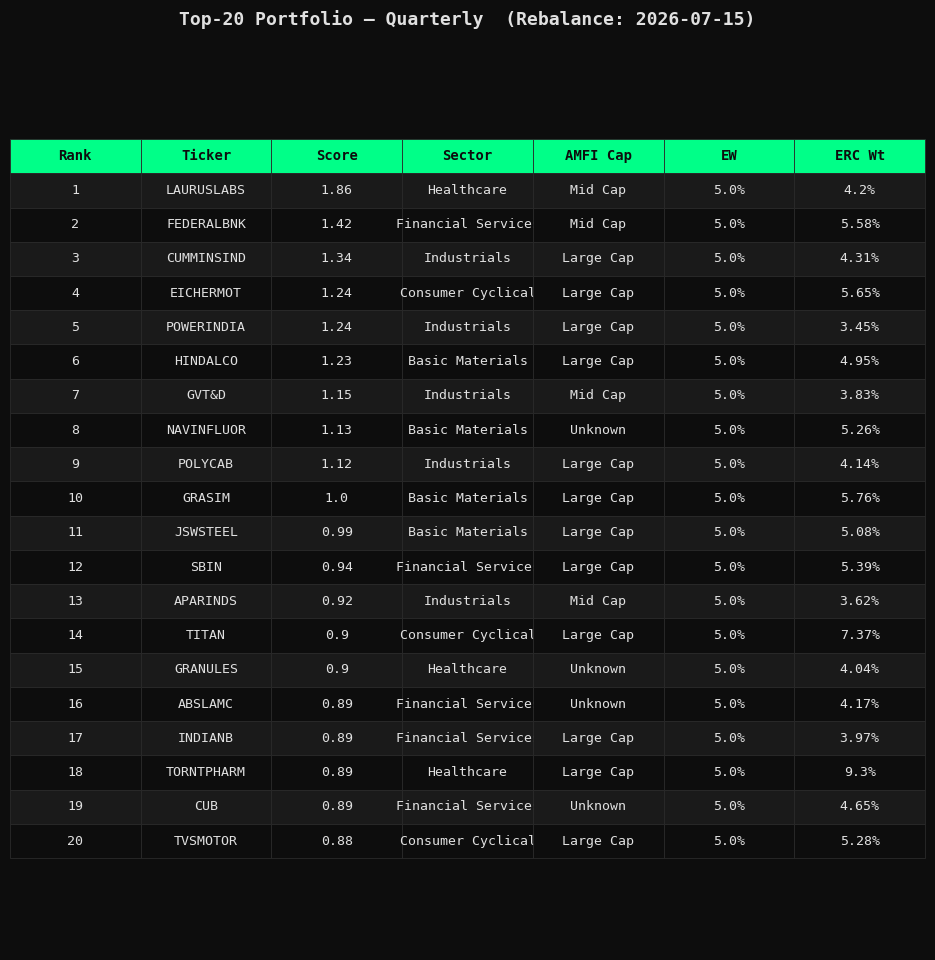

Saved -> .\output\03_research_top20_quarterly.png


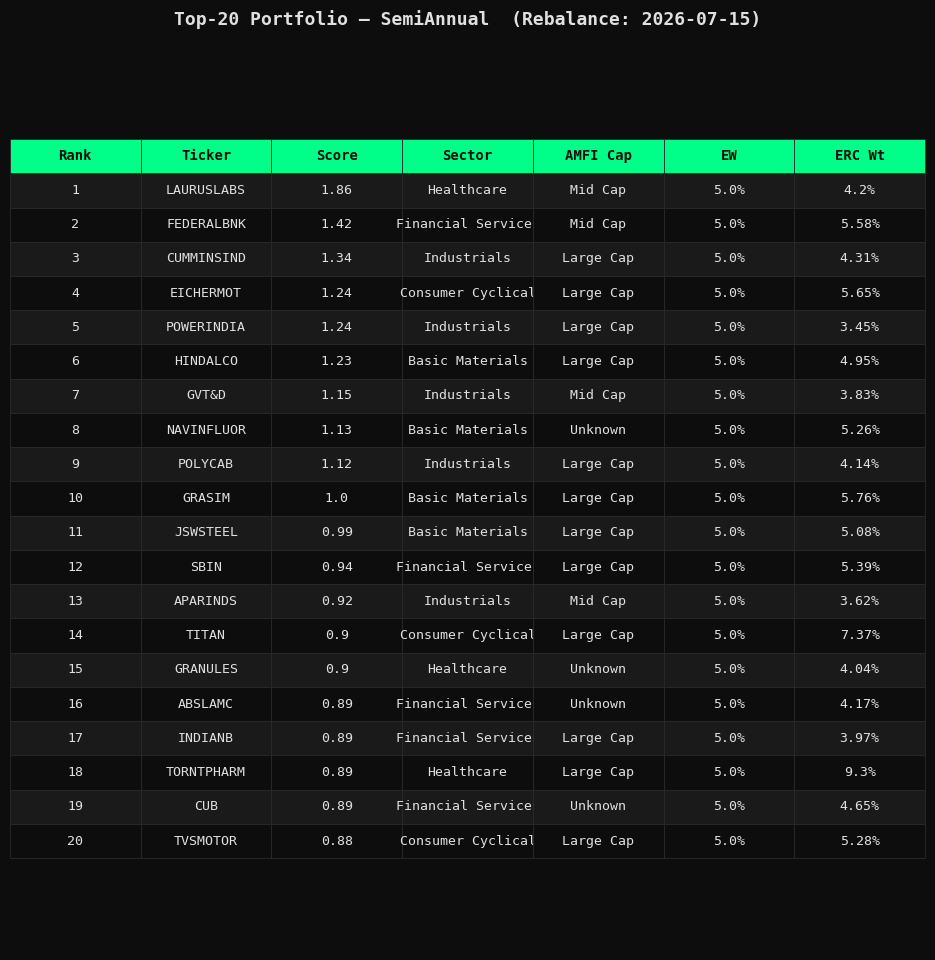

Saved -> .\output\03_research_top20_semiannual.png


In [18]:
def format_top20_table(freq_name):
    rd = REBAL_DATES_BY_FREQ[freq_name][-1]
    sub = ranked_universe_panel[
        (ranked_universe_panel['frequency'] == freq_name) &
        (ranked_universe_panel['rebalance_date'] == rd) &
        (ranked_universe_panel['selected_top20'])
    ].sort_values('rank').copy()

    display_df = pd.DataFrame({
        'Rank':      sub['rank'].astype(int),
        'Ticker':    sub['ticker'].str.replace('.NS', '', regex=False),
        'Score':     sub['composite_score'].round(2),
        'Sector':    sub['sector'],
        'AMFI Cap':  sub['amfi_classification'],
        'EW':        (sub['equal_weight'] * 100).round(2).astype(str) + '%',
        'ERC Wt':    (sub['erc_weight'] * 100).round(2).astype(str) + '%',
    })
    return rd, display_df


for freq_name in REBAL_FREQ_STEP.keys():
    rd, table = format_top20_table(freq_name)
    render_dark_table(
        table, f'Top-20 Portfolio — {freq_name}  (Rebalance: {rd.date()})',
        f'03_research_top20_{freq_name.lower()}.png'
    )


### Research Output 2: Buffer/Watchlist (Ranks 21–30, per Frequency)

The buffer zone — stocks just outside the cutoff — is often as informative to a portfolio manager as
the portfolio itself: it identifies which names are next in line if a held stock's score
deteriorates.

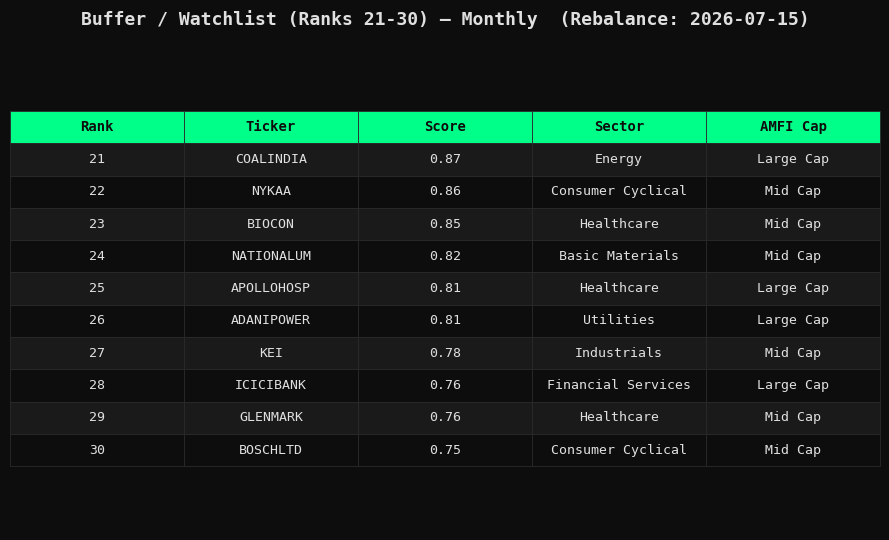

Saved -> .\output\03_research_buffer_monthly.png


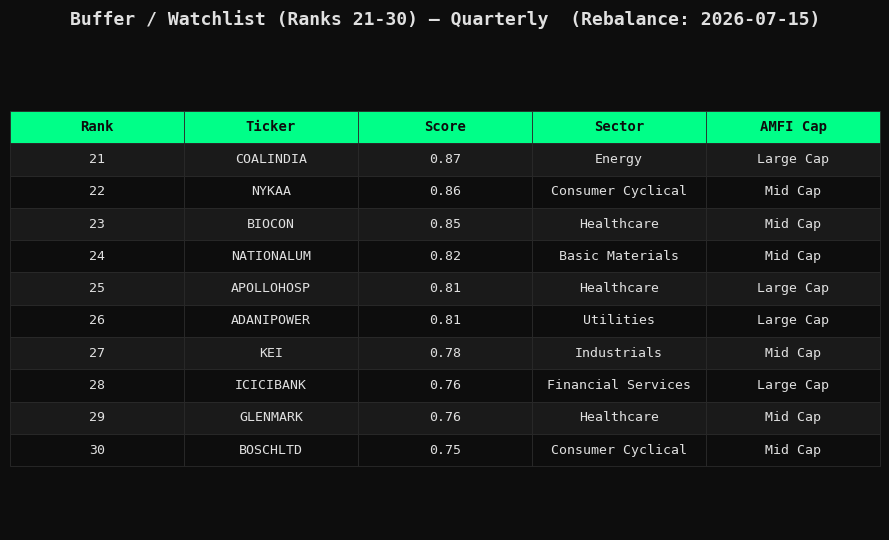

Saved -> .\output\03_research_buffer_quarterly.png


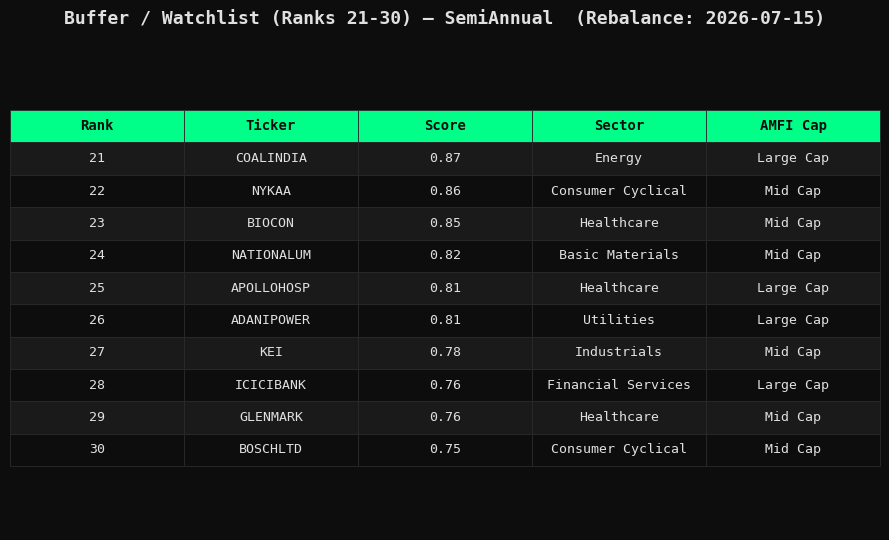

Saved -> .\output\03_research_buffer_semiannual.png


In [19]:
def format_buffer_table(freq_name):
    rd = REBAL_DATES_BY_FREQ[freq_name][-1]
    sub = ranked_universe_panel[
        (ranked_universe_panel['frequency'] == freq_name) &
        (ranked_universe_panel['rebalance_date'] == rd) &
        (ranked_universe_panel['rank'] >= BUFFER_RANK_START) &
        (ranked_universe_panel['rank'] <= BUFFER_RANK_END)
    ].sort_values('rank').copy()

    display_df = pd.DataFrame({
        'Rank':     sub['rank'].astype(int),
        'Ticker':   sub['ticker'].str.replace('.NS', '', regex=False),
        'Score':    sub['composite_score'].round(2),
        'Sector':   sub['sector'],
        'AMFI Cap': sub['amfi_classification'],
    })
    return rd, display_df


for freq_name in REBAL_FREQ_STEP.keys():
    rd, table = format_buffer_table(freq_name)
    if len(table) == 0:
        print(f'{freq_name}: no stocks in the rank {BUFFER_RANK_START}-{BUFFER_RANK_END} '
              f'buffer zone at {rd.date()} (eligible universe smaller than {BUFFER_RANK_START}).')
        continue
    render_dark_table(
        table, f'Buffer / Watchlist (Ranks {BUFFER_RANK_START}-{BUFFER_RANK_END}) — '
               f'{freq_name}  (Rebalance: {rd.date()})',
        f'03_research_buffer_{freq_name.lower()}.png'
    )


### Research Output 3: Sector Allocation of the Selected Portfolio

Compares Equal Weight and ERC sector allocation for the current Top-20 portfolio under each
frequency, since the two weighting schemes can produce materially different sector concentrations even
from the identical set of selected stocks.

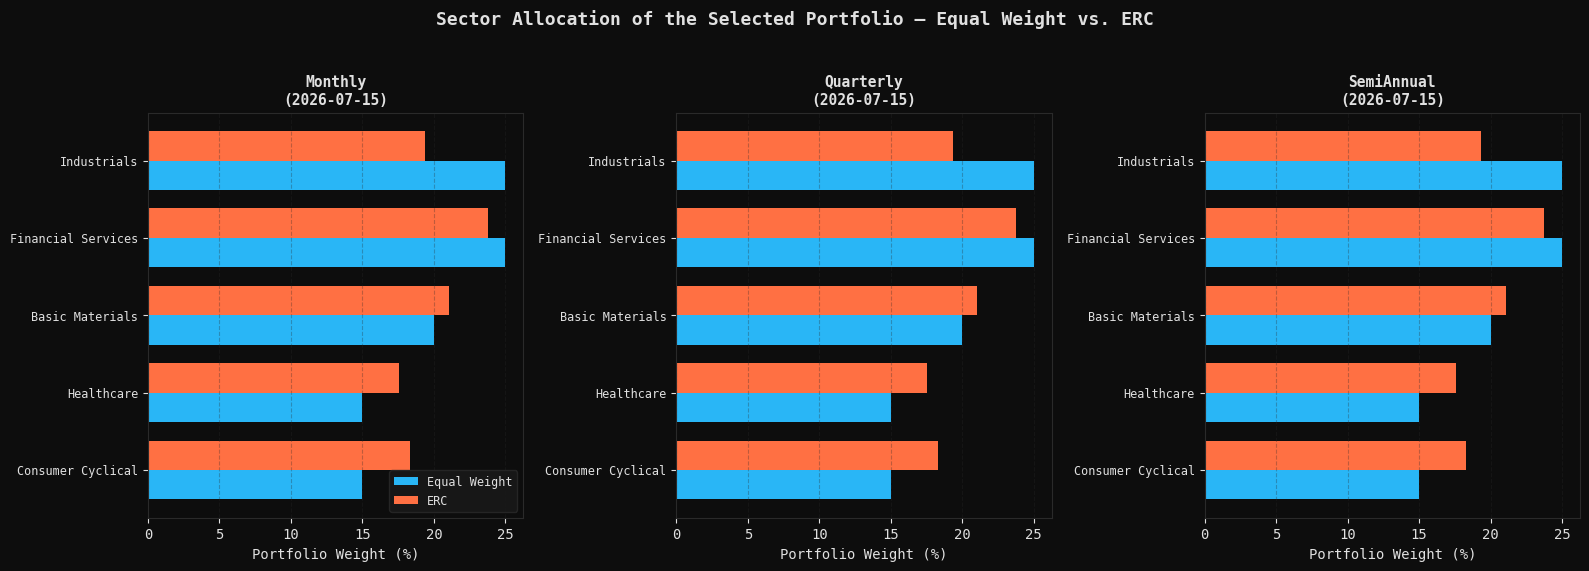

Saved -> .\output\03_research_sector_allocation.png


In [20]:
fig, axes = plt.subplots(1, len(REBAL_FREQ_STEP), figsize=(16, 5.5), sharey=False)

sector_alloc_rows = []
for ax, freq_name in zip(axes, REBAL_FREQ_STEP.keys()):
    rd = REBAL_DATES_BY_FREQ[freq_name][-1]
    sub = ranked_universe_panel[
        (ranked_universe_panel['frequency'] == freq_name) &
        (ranked_universe_panel['rebalance_date'] == rd) &
        (ranked_universe_panel['selected_top20'])
    ]

    by_sector = sub.groupby('sector')[['equal_weight', 'erc_weight']].sum().sort_values(
        'equal_weight', ascending=True
    )
    for sector, r in by_sector.iterrows():
        sector_alloc_rows.append({
            'frequency': freq_name, 'rebalance_date': rd, 'sector': sector,
            'equal_weight_allocation': r['equal_weight'], 'erc_weight_allocation': r['erc_weight'],
        })

    y_pos = np.arange(len(by_sector))
    ax.barh(y_pos - 0.19, by_sector['equal_weight'] * 100, height=0.38,
            color=COLORS[0], label='Equal Weight')
    ax.barh(y_pos + 0.19, by_sector['erc_weight'] * 100, height=0.38,
            color=COLORS[1], label='ERC')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(by_sector.index, fontsize=8.5)
    ax.set_xlabel('Portfolio Weight (%)')
    ax.set_title(f'{freq_name}\n({rd.date()})', fontsize=10.5, fontweight='bold', color=TEXT_COLOR)
    ax.grid(True, axis='x', alpha=0.3)

axes[0].legend(fontsize=8.5, loc='lower right')
fig.suptitle('Sector Allocation of the Selected Portfolio — Equal Weight vs. ERC',
             fontsize=13, fontweight='bold', color=TEXT_COLOR, y=1.03)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_research_sector_allocation.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')

sector_allocation_df = pd.DataFrame(sector_alloc_rows)


### Research Output 4: Large vs. Mid Cap Allocation

Compares Equal Weight and ERC allocation across AMFI Large Cap / Mid Cap classification for the
current Top-20 portfolio under each frequency.

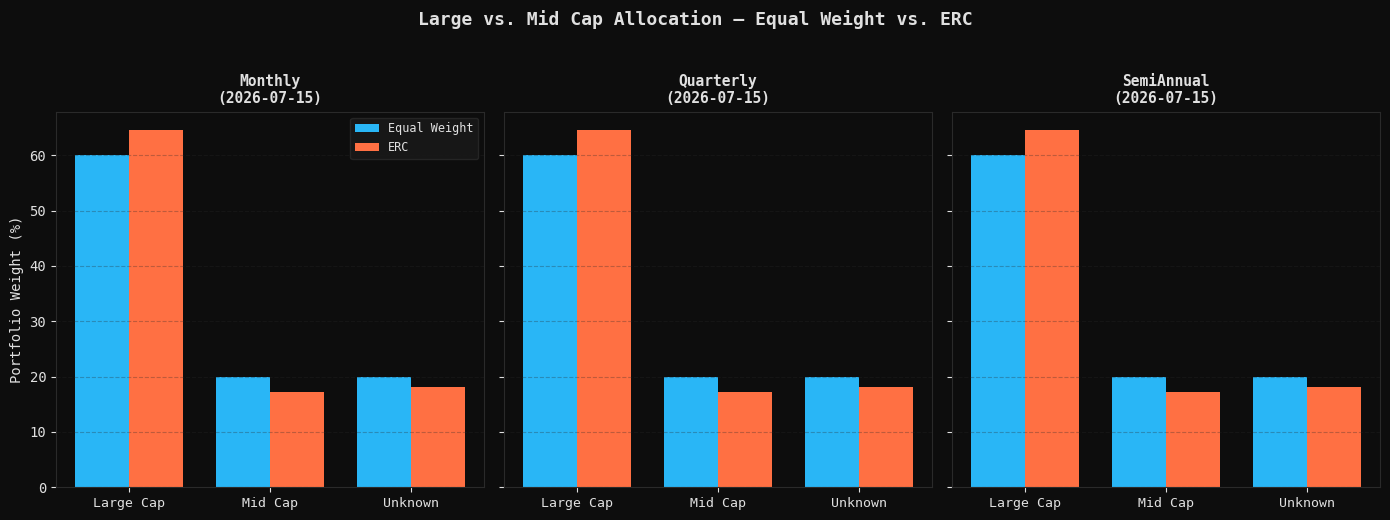

Saved -> .\output\03_research_capclass_allocation.png


In [21]:
fig, axes = plt.subplots(1, len(REBAL_FREQ_STEP), figsize=(14, 5), sharey=True)

capclass_alloc_rows = []
for ax, freq_name in zip(axes, REBAL_FREQ_STEP.keys()):
    rd = REBAL_DATES_BY_FREQ[freq_name][-1]
    sub = ranked_universe_panel[
        (ranked_universe_panel['frequency'] == freq_name) &
        (ranked_universe_panel['rebalance_date'] == rd) &
        (ranked_universe_panel['selected_top20'])
    ]

    by_cap = sub.groupby('amfi_classification')[['equal_weight', 'erc_weight']].sum()
    for cap_class, r in by_cap.iterrows():
        capclass_alloc_rows.append({
            'frequency': freq_name, 'rebalance_date': rd, 'amfi_classification': cap_class,
            'equal_weight_allocation': r['equal_weight'], 'erc_weight_allocation': r['erc_weight'],
        })

    x_pos = np.arange(len(by_cap))
    ax.bar(x_pos - 0.19, by_cap['equal_weight'] * 100, width=0.38, color=COLORS[0], label='Equal Weight')
    ax.bar(x_pos + 0.19, by_cap['erc_weight'] * 100, width=0.38, color=COLORS[1], label='ERC')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(by_cap.index, fontsize=9.5)
    ax.set_title(f'{freq_name}\n({rd.date()})', fontsize=10.5, fontweight='bold', color=TEXT_COLOR)
    ax.grid(True, axis='y', alpha=0.3)

axes[0].set_ylabel('Portfolio Weight (%)')
axes[0].legend(fontsize=8.5)
fig.suptitle('Large vs. Mid Cap Allocation — Equal Weight vs. ERC', fontsize=13, fontweight='bold',
             color=TEXT_COLOR, y=1.03)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_research_capclass_allocation.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')

capclass_allocation_df = pd.DataFrame(capclass_alloc_rows)


### Research Output 5: Stocks Added and Removed at Each Rebalance (Top-20 Only)

Tracks turnover in the selected Top-20 portfolio only, not the full ranked universe — i.e., what
actually changed in the portfolio a portfolio manager would be holding.

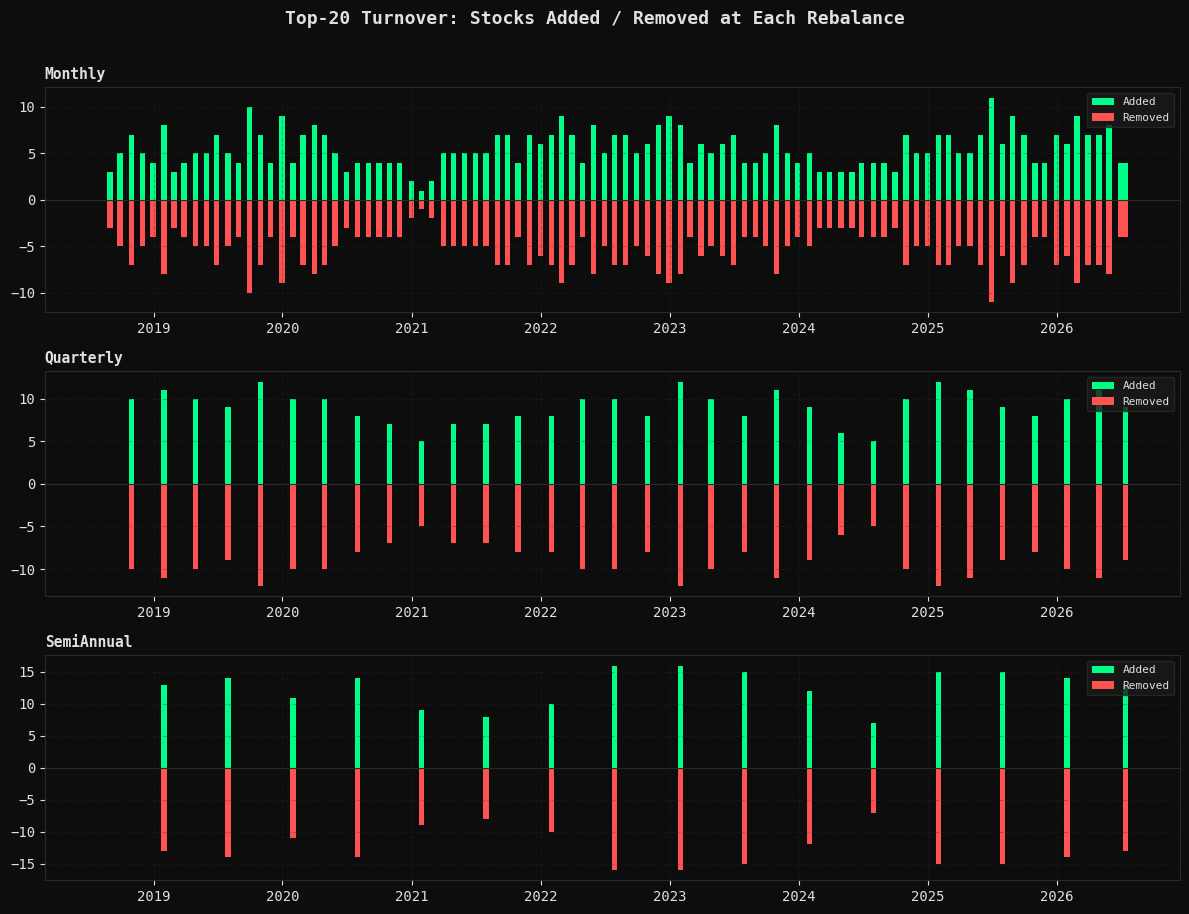

Saved -> .\output\03_research_turnover.png

Median names added / removed per rebalance, by frequency:
            n_added  n_removed
frequency                     
Monthly         5.0        5.0
Quarterly       9.0        9.0
SemiAnnual     13.0       13.0


In [22]:
turnover_rows = []

for freq_name, dates in REBAL_DATES_BY_FREQ.items():
    prev_holdings = None
    for rd in dates:
        current_holdings = set(SELECTIONS[(freq_name, rd)].index)
        if prev_holdings is None:
            added, removed = set(), set()
        else:
            added = current_holdings - prev_holdings
            removed = prev_holdings - current_holdings
        turnover_rows.append({
            'frequency': freq_name, 'rebalance_date': rd,
            'n_added': len(added), 'n_removed': len(removed),
            'added_tickers': ', '.join(sorted(t.replace('.NS', '') for t in added)),
            'removed_tickers': ', '.join(sorted(t.replace('.NS', '') for t in removed)),
        })
        prev_holdings = current_holdings

turnover_log = pd.DataFrame(turnover_rows)

fig, axes = plt.subplots(len(REBAL_FREQ_STEP), 1, figsize=(12, 9), sharex=False)
for ax, freq_name in zip(axes, REBAL_FREQ_STEP.keys()):
    sub = turnover_log[turnover_log['frequency'] == freq_name]
    ax.bar(sub['rebalance_date'], sub['n_added'], color=ACCENT, label='Added', width=15,
           align='center')
    ax.bar(sub['rebalance_date'], -sub['n_removed'], color=ACCENT2, label='Removed', width=15,
           align='center')
    ax.axhline(0, color=GRID_COLOR, linewidth=0.8)
    ax.set_title(freq_name, fontsize=10.5, fontweight='bold', color=TEXT_COLOR, loc='left')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Top-20 Turnover: Stocks Added / Removed at Each Rebalance', fontsize=13,
             fontweight='bold', color=TEXT_COLOR, y=1.01)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_research_turnover.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')

print()
print('Median names added / removed per rebalance, by frequency:')
print(turnover_log.groupby('frequency')[['n_added', 'n_removed']].median().to_string())


Median names added/removed per rebalance scales with frequency as expected: 5 for
Monthly, 9 for Quarterly, 13 for Semi-Annual — consistent with longer gaps between rebalances allowing
more composite-score-driven change to accumulate before each reconstitution.

### Research Output 6: Selection Frequency (How Often Each Stock Was Selected)

Reported separately per frequency, since Monthly, Quarterly, and Semi-Annual each have a different
number of rebalance dates — a raw count would not be comparable across frequencies, so this is
expressed as a percentage of that frequency's own rebalance dates.

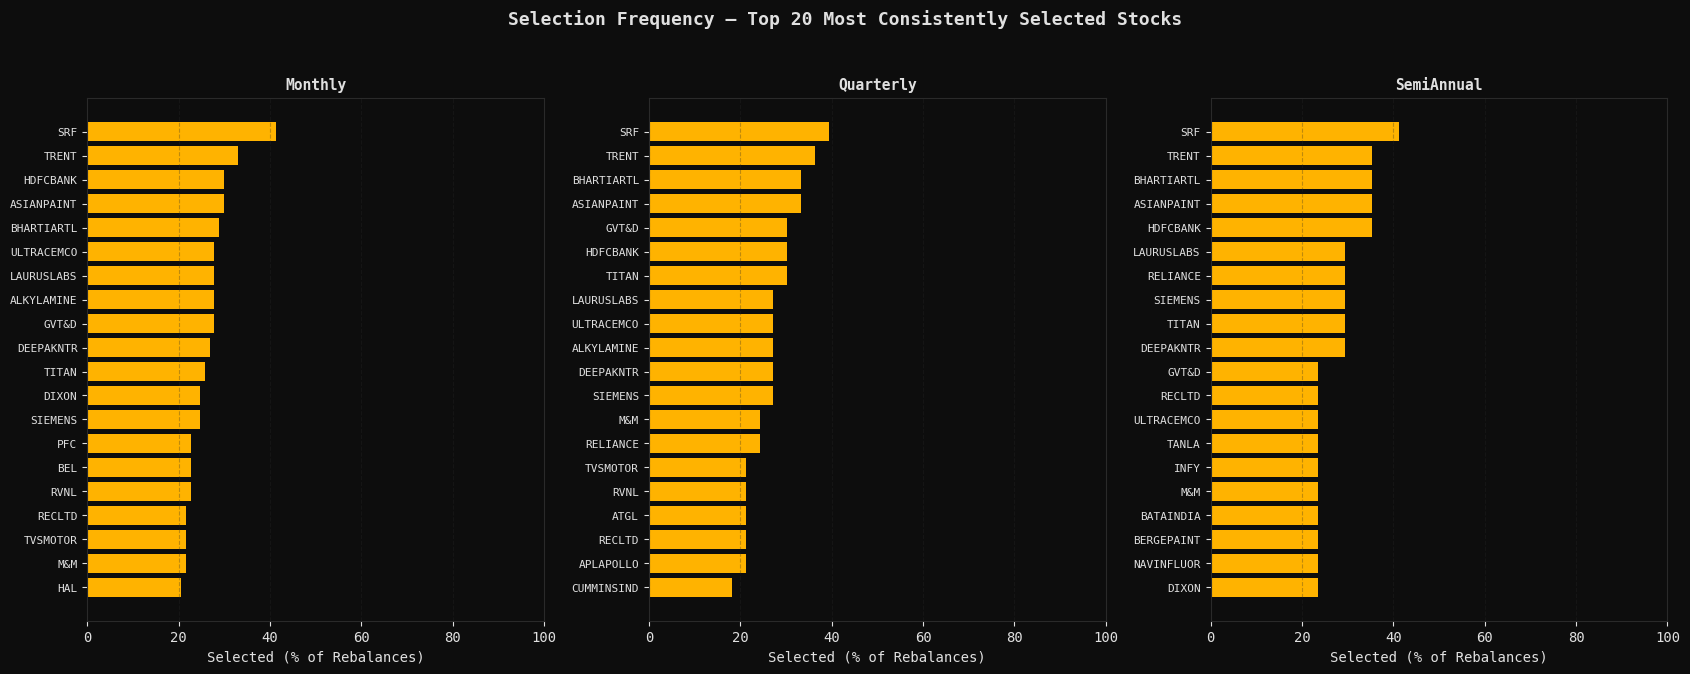

Saved -> .\output\03_research_selection_frequency.png


In [23]:
selection_freq_rows = []
for freq_name, dates in REBAL_DATES_BY_FREQ.items():
    n_rebalances = len(dates)
    counts = {}
    for rd in dates:
        for ticker in SELECTIONS[(freq_name, rd)].index:
            counts[ticker] = counts.get(ticker, 0) + 1
    for ticker, cnt in counts.items():
        selection_freq_rows.append({
            'frequency': freq_name, 'ticker': ticker, 'times_selected': cnt,
            'n_rebalances': n_rebalances, 'selection_pct': 100.0 * cnt / n_rebalances,
        })

selection_frequency_df = pd.DataFrame(selection_freq_rows)

fig, axes = plt.subplots(1, len(REBAL_FREQ_STEP), figsize=(17, 6.5), sharex=True)
for ax, freq_name in zip(axes, REBAL_FREQ_STEP.keys()):
    sub = selection_frequency_df[selection_frequency_df['frequency'] == freq_name].sort_values(
        'selection_pct', ascending=True
    ).tail(TOP_FREQ_CHART_N)
    y_pos = np.arange(len(sub))
    colors_bar = [ACCENT if v >= 50 else COLORS[4] for v in sub['selection_pct']]
    ax.barh(y_pos, sub['selection_pct'], color=colors_bar)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([t.replace('.NS', '') for t in sub['ticker']], fontsize=8)
    ax.set_xlabel('Selected (% of Rebalances)')
    ax.set_title(freq_name, fontsize=10.5, fontweight='bold', color=TEXT_COLOR)
    ax.grid(True, axis='x', alpha=0.3)
    ax.set_xlim(0, 100)

fig.suptitle(f'Selection Frequency — Top {TOP_FREQ_CHART_N} Most Consistently Selected Stocks',
             fontsize=13, fontweight='bold', color=TEXT_COLOR, y=1.03)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_research_selection_frequency.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Research Output 7: Composite Score Ranking Chart (Latest Rebalance)

Visualises the full composite-score ranking at the latest Monthly rebalance, colour-coding the
selected Top 20, the ranks-21–30 buffer zone, and everything beyond it, to show how close the cutoff
is to the buffer zone in score terms rather than only in rank terms.

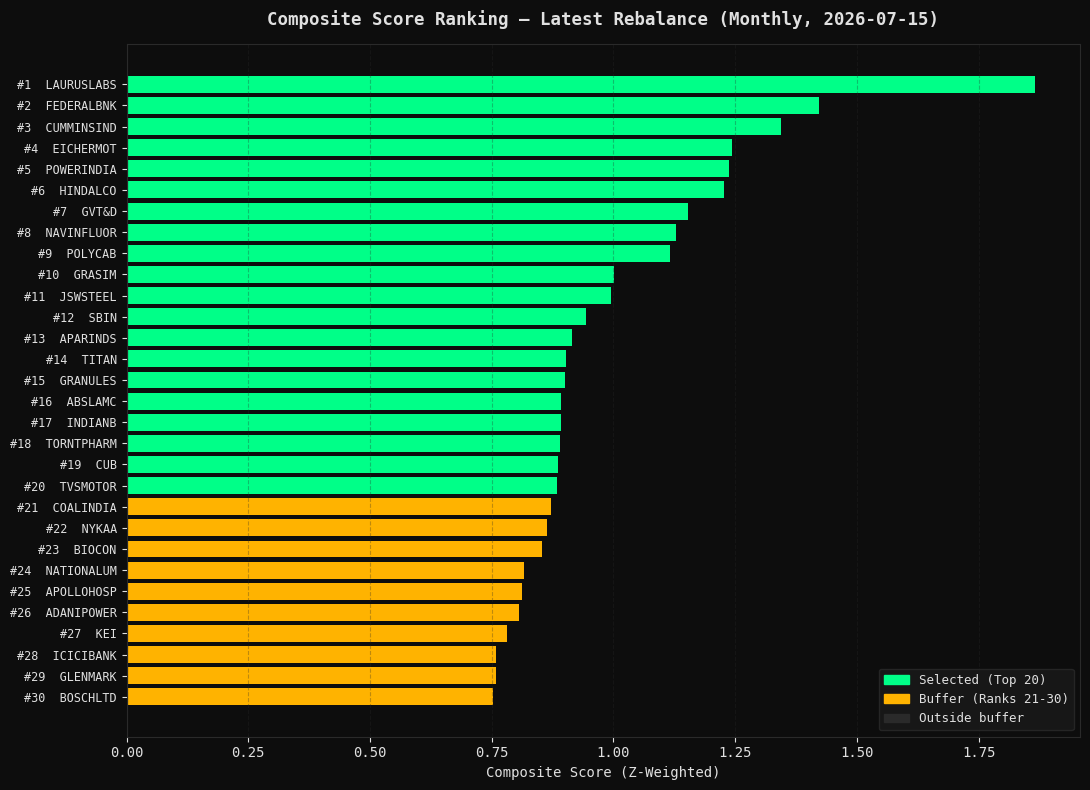

Saved -> .\output\03_research_composite_score_ranking.png


In [24]:
_latest_freq = 'Monthly'
_latest_rd = REBAL_DATES_BY_FREQ[_latest_freq][-1]

chart_sub = ranked_universe_panel[
    (ranked_universe_panel['frequency'] == _latest_freq) &
    (ranked_universe_panel['rebalance_date'] == _latest_rd) &
    (ranked_universe_panel['rank'] <= RANK_CHART_TOP_N)
].sort_values('rank')

bar_colors = []
for _, r in chart_sub.iterrows():
    if r['selected_top20']:
        bar_colors.append(ACCENT)
    elif BUFFER_RANK_START <= r['rank'] <= BUFFER_RANK_END:
        bar_colors.append('#FFB300')
    else:
        bar_colors.append(GRID_COLOR)

fig, ax = plt.subplots(figsize=(11, 8))
y_pos = np.arange(len(chart_sub))
ax.barh(y_pos, chart_sub['composite_score'], color=bar_colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f"#{int(rank)}  {t.replace('.NS', '')}" for rank, t in zip(chart_sub['rank'], chart_sub['ticker'])],
    fontsize=8.5
)
ax.invert_yaxis()
ax.axvline(0, color=GRID_COLOR, linewidth=0.8)
ax.set_xlabel('Composite Score (Z-Weighted)')
ax.set_title(f'Composite Score Ranking — Latest Rebalance ({_latest_freq}, {_latest_rd.date()})',
             fontsize=12.5, fontweight='bold', color=TEXT_COLOR, pad=14)
ax.grid(True, axis='x', alpha=0.3)

legend_elems = [
    mpatches.Patch(color=ACCENT, label=f'Selected (Top {TARGET_PORTFOLIO_SIZE})'),
    mpatches.Patch(color='#FFB300', label=f'Buffer (Ranks {BUFFER_RANK_START}-{BUFFER_RANK_END})'),
    mpatches.Patch(color=GRID_COLOR, label='Outside buffer'),
]
ax.legend(handles=legend_elems, fontsize=9, loc='lower right')

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_research_composite_score_ranking.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Save Portfolio Research Diagnostics to data/

Persists the turnover log, selection frequency, sector allocation, and cap-class allocation tables —
all Portfolio Research section outputs — for reuse in Notebook 05.

In [25]:
turnover_log.to_csv(os.path.join(DATA_DIR, 'portfolio_turnover_log.csv'), index=False)
selection_frequency_df.to_csv(os.path.join(DATA_DIR, 'selection_frequency.csv'), index=False)
sector_allocation_df.to_csv(os.path.join(DATA_DIR, 'sector_allocation.csv'), index=False)
capclass_allocation_df.to_csv(os.path.join(DATA_DIR, 'capclass_allocation.csv'), index=False)

print('Saved to data/:')
for f in ['ranked_universe_panel.csv', 'ticker_sector_map.csv', 'portfolio_turnover_log.csv',
          'selection_frequency.csv', 'sector_allocation.csv', 'capclass_allocation.csv']:
    print(f'  {f}')

print()
print('Portfolio Research section complete -- all outputs above are for interpretation/review only '
      'and were not used anywhere in the construction logic (Cells 1-12).')


Saved to data/:
  ranked_universe_panel.csv
  ticker_sector_map.csv
  portfolio_turnover_log.csv
  selection_frequency.csv
  sector_allocation.csv
  capclass_allocation.csv

Portfolio Research section complete -- all outputs above are for interpretation/review only and were not used anywhere in the construction logic (Cells 1-12).


---
## Results

- Portfolio holdings panel: 5,880 rows (147 (frequency, rebalance date) combinations × 2 weighting
  schemes × 20 stocks), with 0 of 294 (frequency, scheme, date) weight groups failing to sum to 1.0.
- Every one of the 147 (frequency, rebalance date) combinations reached the full 20-stock target — no
  under-sized-portfolio fallback was triggered.
- ERC diagnostics: 65 of 148 logged attempts required covariance shrinkage (near-singular raw
  estimate); 0 fell back to Equal Weight for insufficient history; 0 failed to converge.
- Median effective N (1/HHI): Equal Weight exactly 20.00 at every frequency; ERC 19.17 (Monthly), 19.11
  (Quarterly), 19.07 (Semi-Annual).
- Sector coverage: 383/404 tickers (94.8%) with a known sector, 21 `Unknown`.
- Ranked-universe panel: 49,071 rows (2,940 selected, 46,131 non-selected).
- Median Top-20 turnover per rebalance: 5 names (Monthly), 9 (Quarterly), 13 (Semi-Annual).

## Interpretation

ERC's effective N sits only marginally below Equal Weight's exact 20 (19.07–19.17 versus 20.00),
indicating the risk-based tilt is present but modest rather than a source of material concentration —
consistent with the ERC objective distributing risk, not capital, equally, over a Top-20 universe that
has already been pre-filtered by the composite factor score. Covariance shrinkage triggers on 44% of
logged ERC attempts (65/148), clustering at the start of the backtest window where trailing history is
shortest relative to the number of selected stocks — the expected pattern for a fixed 756-day lookback
applied from the first live rebalance onward, not evidence of a broader estimation problem. Turnover
scales roughly proportionally with the gap between rebalances (5 → 9 → 13 names as frequency lengthens
from Monthly to Semi-Annual), consistent with more composite-score drift accumulating between more
widely spaced reconstitution dates.

## Key Findings

The 20-stock target portfolio size was achieved at every rebalance date across all three frequencies
with no under-sized-portfolio fallback required, and the ERC optimizer never fell back to Equal Weight
or failed to converge across 148 logged attempts — its only recorded stress response was covariance
shrinkage, applied automatically and logged whenever the raw estimate was near-singular. The Portfolio
Research section confirms Equal Weight and ERC select from an identical Top-20 stock set at every
rebalance date but can allocate that capital differently across sectors and cap classes, since only the
weighting — not the selection — differs between schemes.

## Limitations

- No additional liquidity filter was applied beyond the factor panel's existing history requirement —
  an explicit design decision, not an oversight; if revisited in future work, it should be revisited
  deliberately.
- Sector/industry coverage is 94.8%, with the remaining 5.2% labelled `Unknown` rather than imputed,
  per yfinance's disclosed coverage limitations for some NSE mid-caps.
- This notebook produces weights only; no performance, transaction cost, or compounding logic is
  present here, per the confirmed scope boundary stated above.

## Next Notebook

Notebook 04 (Walk-Forward Backtest) consumes `data/portfolio_holdings.csv` to compound daily returns
under weight drift between rebalances, applying transaction costs to produce Gross and Net cumulative
return series for all six (frequency × weighting scheme) combinations.